# Analysis of Outcomes

In [427]:
import pandas as pd
df = pd.read_csv("output.csv")

## Likert Scale Plots

In [428]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_likert(df, field_value, likert_map):
    """
    Centered (diverging) Likert distribution plot for a single question.
    Positive (lower scores) appear at the top, negative (higher scores) at the bottom.
    Median/mean bar is centered on the 0 line, half-width left/right, count displayed to the right.
    Count labels appear at the end of each bar.
    Bars thicker, y-axis labels bold.
    Reference dashed lines at ±25%, ±50%, ±75%.
    X-axis limited to ±75%.
    Saves the plot as 'plots/<field_value>.pdf'.
    """

    # --- Validate columns ---
    for col in ["field", "value"]:
        if col not in df.columns:
            raise KeyError(f"Missing required column: '{col}'")

    # --- Filter data ---
    filtered = df[df["field"] == field_value].copy()
    if filtered.empty:
        print(f"No data found for field = {field_value}")
        return

    # --- Detect mapping direction ---
    first_key = next(iter(likert_map))
    if isinstance(first_key, str):
        label_to_score = likert_map
        score_to_label = {v: k for k, v in likert_map.items()}
    else:
        score_to_label = likert_map
        label_to_score = {v: k for k, v in likert_map.items()}

    # --- Convert 'value' to numeric ---
    try:
        filtered["score"] = filtered["value"].astype(int)
        filtered["label"] = filtered["score"].map(score_to_label)
    except ValueError:
        filtered["label"] = filtered["value"]
        filtered["score"] = filtered["value"].map(label_to_score)

    # --- Handle unmapped values ---
    if filtered["score"].isna().any():
        unmapped = filtered.loc[filtered["score"].isna(), "value"].unique()
        print(f"⚠️ Unmapped Likert values found: {list(unmapped)}")

    # --- Sort Likert scale order numerically ---
    order = sorted(score_to_label.items(), key=lambda x: x[0])
    scores = [s for s, _ in order]
    labels = [l for _, l in order]
    counts = filtered["label"].value_counts().reindex(labels, fill_value=0)
    total = counts.sum()
    percents = (counts / total) * 100

    # --- Median/Mean (round up if necessary) ---
    median_score = int(np.median(scores))
    neutral_label = score_to_label.get(median_score, None)

    # --- Build color map (green → red) ---
    norm_vals = (np.array(scores) - min(scores)) / (max(scores) - min(scores))
    colors = plt.cm.RdYlGn_r(norm_vals)
    color_map = dict(zip(labels, colors))

    # --- Split sides ---
    pos_labels = [l for s, l in order if s < median_score]  # lower = positive
    neg_labels = [l for s, l in order if s > median_score]  # higher = negative

    # --- Combine all labels for consistent y-axis order (top-to-bottom) ---
    full_order = pos_labels[::-1] + ([neutral_label] if neutral_label else []) + neg_labels

    # --- Plot ---
    n_bars = len(full_order)
    fig_height = max(3, n_bars * 0.5)
    fig, ax = plt.subplots(figsize=(7, fig_height))
    bar_height = 0.45

    # Plot positive bars (right side)
    for l in pos_labels:
        ax.barh(l, percents[l], color=color_map[l], edgecolor="none", height=bar_height)
        ax.text(percents[l] + 1, l, f"{counts[l]}", va="center", ha="left", fontsize=9, color="#333")

    # Plot neutral/median bar (centered)
    if neutral_label:
        width = percents[neutral_label]
        ax.barh(neutral_label, width, left=-width/2, color=color_map[neutral_label],
                edgecolor="none", height=bar_height)
        # Place count at the right end of the bar
        ax.text(width/2 + 1, neutral_label, f"{counts[neutral_label]}", va="center", ha="left",
                fontsize=9, color="#333")

    # Plot negative bars (left side)
    for l in neg_labels:
        ax.barh(l, -percents[l], color=color_map[l], edgecolor="none", height=bar_height)
        ax.text(-percents[l] - 1, l, f"{counts[l]}", va="center", ha="right", fontsize=9, color="#333")

    # --- Reference dashed lines at ±25, ±50, ±75 ---
    for x in [-75, -50, -25, 25, 50, 75]:
        ax.axvline(x=x, color='lightgray', linestyle='--', linewidth=0.8, alpha=0.7)
    # Center line
    ax.axvline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

    # --- Aesthetics ---
    ax.set_xlabel("Percentage of Responses (%)", fontsize=11)
    ax.set_title(field_value, fontsize=13, weight="bold", pad=12)

    # Limit x-axis to ±75%
    ax.set_xlim(-75, 75)
    ax.set_xticks(np.arange(-75, 76, 25))
    ax.set_xticklabels([f"{abs(x)}%" for x in np.arange(-75, 76, 25)])
    ax.set_yticks(full_order)
    ax.set_yticklabels(full_order, fontweight='bold')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#aaa")
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(False)

    # --- Save figure ---
    os.makedirs("plots", exist_ok=True)
    plt.tight_layout()

    plt.savefig(f"plots/{field_value}.pdf", dpi=600)
    plt.show()


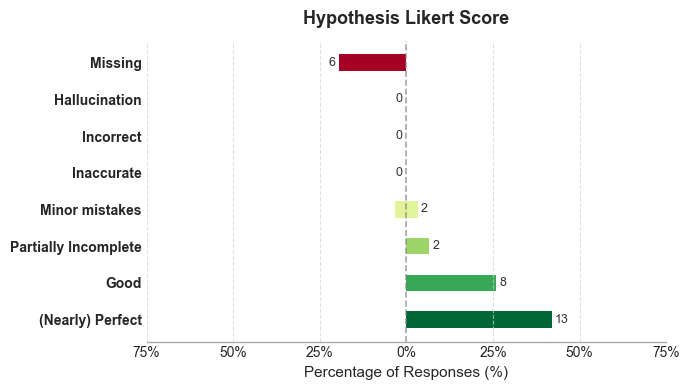

In [429]:
# Generate the Plot for Hypothesis
plot_likert(
    df=df,
    field_value='Hypothesis Likert Score',
    likert_map= {
        "(Nearly) Perfect": 1,
        "Good": 2,
        "Partially Incomplete": 3,
        "Minor mistakes": 4,
        "Inaccurate": 5,
        "Incorrect": 6,
        "Hallucination": 7,
        "Missing": 8,
    }
)

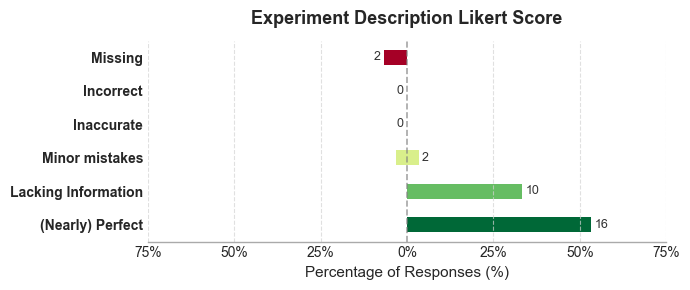

In [430]:
# This is the specific value you want to plot (e.g., the name of the question)
FILTER_VALUE_PLACEHOLDER = 'Experiment Description Likert Score'

# 3. Generate the Plot
plot_likert(
    df=df,
    field_value=FILTER_VALUE_PLACEHOLDER,
    likert_map= {
        "(Nearly) Perfect": 1,
        "Lacking Information": 2,
        "Minor mistakes": 3,
        "Inaccurate": 4,
        "Incorrect": 5,
        "Missing": 6,
    }
)

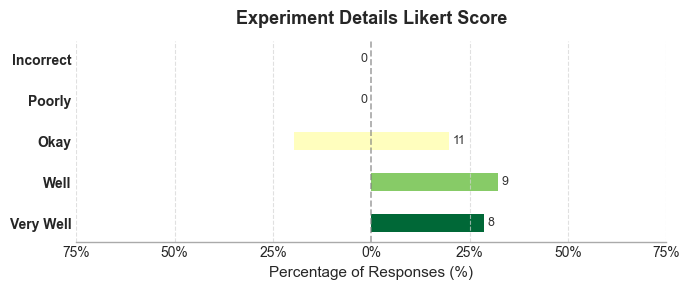

In [431]:
# This is the specific value you want to plot (e.g., the name of the question)
FILTER_VALUE_PLACEHOLDER = 'Experiment Details Likert Score'

# 3. Generate the Plot
plot_likert(
    df=df,
    field_value=FILTER_VALUE_PLACEHOLDER,
    likert_map= {
        "Very Well": 1,
        "Well": 2,
        "Okay": 3,
        "Poorly": 4,
        "Incorrect": 5,
    }
)

In [432]:
df[df["field"] == "Experiment Details Likert Score"]

,Paper,section,field,value
58,Robustness Distributions in Neural Network Ver...,experiment_1,Experiment Details Likert Score,3
69,Robustness Distributions in Neural Network Ver...,experiment_2,Experiment Details Likert Score,3
80,Robustness Distributions in Neural Network Ver...,experiment_3,Experiment Details Likert Score,3
143,Instance selection for configuration performan...,experiment_1,Experiment Details Likert Score,3
154,Instance selection for configuration performan...,experiment_2,Experiment Details Likert Score,1
190,Edge-Based Graph Component Pooling,experiment_1,Experiment Details Likert Score,2
228,Combining Automated Optimisation of Hyperparam...,experiment_1,Experiment Details Likert Score,2
281,Hyperparameters in Reinforcement Learning and ...,experiment_1,Experiment Details Likert Score,2
292,Hyperparameters in Reinforcement Learning and ...,experiment_2,Experiment Details Likert Score,1
336,Empirical Analysis of Upper Bounds for Robustn...,experiment_1,Experiment Details Likert Score,2


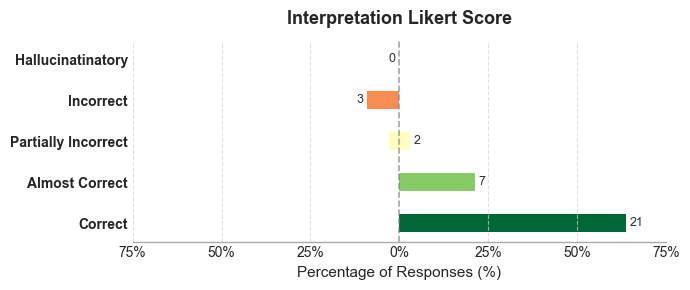

In [433]:
# This is the specific value you want to plot (e.g., the name of the question)
FILTER_VALUE_PLACEHOLDER = 'Interpretation Likert Score'

# 3. Generate the Plot
plot_likert(
    df=df,
    field_value=FILTER_VALUE_PLACEHOLDER,
    likert_map= {
        "Correct": 1,
        "Almost Correct": 2,
        "Partially Incorrect": 3,
        "Incorrect": 4,
        "Hallucinatinatory": 5,
    }
)

## Calculate Metrics for the paper

In [434]:
# Calculate corrected strings
sub_df = df[df["field"] == "Hypothesis corrected"]
corrected_hypothesis_statements = (sub_df['value'].notna()).sum()
corrected_hypothesis_statements_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Hypothesis: {corrected_hypothesis_statements} ({corrected_hypothesis_statements_p:.2f}%)")

sub_df = df[df["field"] == "Interpretation Corrected"]
corrected_interpretation_statements = (sub_df['value'].notna()).sum()
corrected_interpretation_statements_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Hypothesis: {corrected_interpretation_statements} ({corrected_interpretation_statements_p:.2f}%)")


Number of corrected Hypothesis: 16 (64.00%)
Number of corrected Hypothesis: 8 (24.24%)


In [435]:
# Calculate how many links between hypthesis, experiments and interpretation were made
sub_df = df[df["field"] == "Experiment Corrected Hypotheses"]
experiment_corrected_hypotheses = (sub_df['value'].notna()).sum()
experiment_corrected_hypotheses_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Experiment Hypothesis links: {experiment_corrected_hypotheses} ({experiment_corrected_hypotheses_p:.2f}%)")
sub_df = df[df["field"] == "Interpretation Corrected Hypotheses"]
interpretation_corrected_hypotheses = (sub_df['value'].notna()).sum()
interpretation_corrected_hypotheses_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Interpretation Hypothesis links: {interpretation_corrected_hypotheses} ({interpretation_corrected_hypotheses_p:.2f}%)")
sub_df = df[df["field"] == "Interpretation Corrected Experiments"]
interpretation_corrected_experiments = (sub_df['value'].notna()).sum()
interpretation_corrected_experiments_p = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Number of corrected Interpretation Experiments links: {interpretation_corrected_experiments} ({interpretation_corrected_experiments_p:.2f}%)")

Number of corrected Experiment Hypothesis links: 4 (14.29%)
Number of corrected Interpretation Hypothesis links: 0 (0.00%)
Number of corrected Interpretation Experiments links: 2 (6.06%)


In [436]:
# Calculate how many mistakes were made in experiment details
sub_df = df[df["field"] == "Experiment Results Missing"]
missing_results = sub_df['value'].astype(int).sum()
print("Number of missing Experiment Results:", missing_results)

sub_df = df[df["field"] == "Experiment Results Wrong"]
wrong_results = sub_df['value'].astype(int).sum()
print("Number of wrong Experiment Results:", wrong_results)

sub_df = df[df["field"] == "Experiment Results Correct"]
corrected_results = sub_df['value'].astype(int).sum()
print("Number of correct Experiment Results:", corrected_results)
mistake_percentage_results = ((missing_results + wrong_results) / (corrected_results + missing_results + wrong_results)) * 100
print(f"Mistake percentage: {mistake_percentage_results:.2f}%")
print()

sub_df = df[df["field"] == "Experiment Corrected Metrics"]
corrected_metrics = (sub_df['value'].notna()).sum()
corrected_metrics_percentage = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Percentage of Experiment Corrected Metrics: {corrected_metrics_percentage:.2f}%")

sub_df = df[df["field"] == "Experiment Corrected Statistics"]
corrected_statistics = (sub_df['value'].notna()).sum()
corrected_statistics_percentage = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Percentage of Experiment Corrected Statistics: {corrected_statistics_percentage:.2f}%")

sub_df = df[df["field"] == "Experiment Corrected Strategy"]
corrected_strategy = (sub_df['value'].notna()).sum()
corrected_strategy_percentage = ((sub_df['value'].notna()).sum() / len(sub_df)) * 100
print(f"Percentage of Experiment Corrected Strategy: {corrected_strategy_percentage:.2f}%")



Number of missing Experiment Results: 1037
Number of wrong Experiment Results: 66
Number of correct Experiment Results: 461
Mistake percentage: 70.52%

Percentage of Experiment Corrected Metrics: 39.29%
Percentage of Experiment Corrected Statistics: 17.86%
Percentage of Experiment Corrected Strategy: 25.00%


In [437]:
# Create latex table

latex_table = r"""
\begin{table}[]
    \centering
    \begin{tabular}{l|rr}"""\
+ f"""
         & Error \# & Proportion  \\\\
        Hypothesis Statements & {corrected_hypothesis_statements} & {corrected_hypothesis_statements_p:.2f} \% \\\\
        Interpretation Statements & {corrected_interpretation_statements} & {corrected_interpretation_statements_p:.2f} \%  \\\\
        \hline
        Experiment Hypothesis links & {experiment_corrected_hypotheses} & {experiment_corrected_hypotheses_p:.2f} \% \\\\
        Interpretation Hypothesis links & {interpretation_corrected_hypotheses} & {interpretation_corrected_hypotheses_p:.2f} \% \\\\
        Interpretation Experiment links & {interpretation_corrected_experiments} & {interpretation_corrected_experiments_p:.2f} \% \\\\
        \hline
        Experiment Metrics & {corrected_metrics} & {corrected_metrics_percentage:.2f} \% \\\\
        Experiment Statistics & {corrected_statistics} & {corrected_statistics_percentage:.2f} \% \\\\
        Experiment Strategy & {corrected_strategy} & {corrected_strategy_percentage:.2f} \% \\\\
        Experiment Results & {missing_results + wrong_results} & {mistake_percentage_results:.2f} \% \\\\
"""\
+ r"""
    \end{tabular}
    \caption{Error rates of the method on phrasing hypotheses and interpretations, extracting links in the problem statement, experiment details and results.}
    \label{tab:pipeline_mistakes}
\end{table}
"""
print(latex_table)


\begin{table}[]
    \centering
    \begin{tabular}{l|rr}
         & Error \# & Proportion  \\
        Hypothesis Statements & 16 & 64.00 \% \\
        Interpretation Statements & 8 & 24.24 \%  \\
        \hline
        Experiment Hypothesis links & 4 & 14.29 \% \\
        Interpretation Hypothesis links & 0 & 0.00 \% \\
        Interpretation Experiment links & 2 & 6.06 \% \\
        \hline
        Experiment Metrics & 11 & 39.29 \% \\
        Experiment Statistics & 5 & 17.86 \% \\
        Experiment Strategy & 7 & 25.00 \% \\
        Experiment Results & 1103 & 70.52 \% \\

    \end{tabular}
    \caption{Error rates of the method on phrasing hypotheses and interpretations, extracting links in the problem statement, experiment details and results.}
    \label{tab:pipeline_mistakes}
\end{table}



<>:20: SyntaxWarning: invalid escape sequence '\#'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\#'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid e